# Import Library

In [2]:
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read & Analyze Data

In [3]:
file_path = 'training_data.csv'
df = pd.read_csv(file_path)
df.head()

,size (square feet),number of bedrooms,price ($)
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


- Comment:

    * The dataset consist of 3 numerical columns.

    * `size (square feet)` and `number of bedrooms` act as the input features (independent variables - X).

    * `price ($)` acts as the target variable (dependent variable - y) that we want to predict.

In [4]:
df.describe()

,size (square feet),number of bedrooms,price ($)
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


- Comment:

    * The dataset contains 46 samples in total.

    * There is a significant difference in the scale of the features. For example, `size` values are in the thousands, whereas `number of bedrooms` values range only from 1 to 5.

    * Because of this large discrepancy, **feature standardization** is necessary before training. This will ensure that the Gradient Descent algorithm converges efficiently and no single feature dominates the learning process.

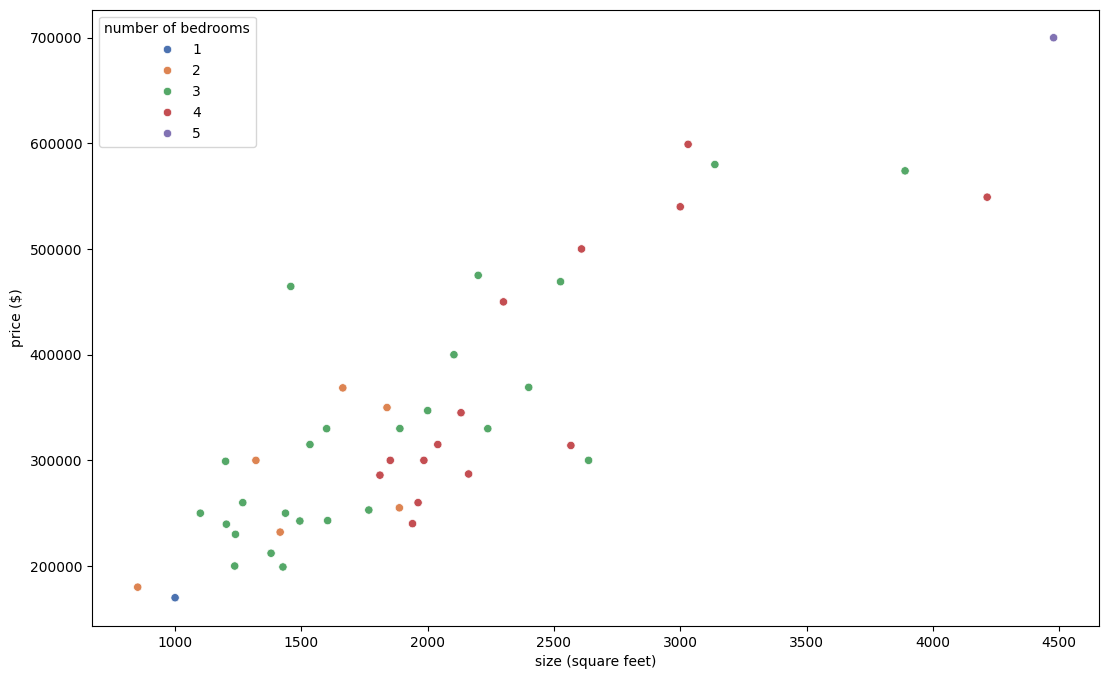

In [5]:
plt.figure(figsize=(13,8))
ax = sns.scatterplot(data=df, x='size (square feet)', y='price ($)', 
                     hue='number of bedrooms', palette='deep')
plt.show()

- Comment:

    * The scatter plot reveals a strong **positive linear correlation** between the size of the house and its price (larger houses tend to be more expensive).

    * The number of bedrooms also contributes to the price, with darker points (more bedrooms) generally appearing higher on the price axis.

    * Given this clear linear relationship, applying a **Multivariate Linear Regression** model is a highly suitable approach for this dataset.

# Helper Functions

In [6]:
def standardize_train_set(X):
    # Calculate mean of each feature (axis=0)
    mu = np.mean(X, axis=0)
    # Calculate standard deviation of each feature
    sigma = np.std(X, axis=0)
    # Normalize the training set
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [7]:
def standardize_test_set(X, mu, sigma):
    # Return the normalized test set using the mean and standard deviation from the training set
    return (X - mu) / sigma

In [ ]:
class LinearRegression:
    def __init__(self, alpha=0.001, iters=1000, verbose=False):
        self.alpha = alpha
        self.iters = iters
        self.verbose = verbose
        self.theta = None
    
    def calculate_absolute_error(self, X, y, theta):
        # Calculate the predicted values (h_theta) using the current parameters (theta)
        h_theta = np.dot(X, theta) # h_theta = theta0 + theta1 * x1 + theta2 * x2 + ...
        # Return the mean absolute error between the predicted values and the actual target values (y)
        return np.mean(np.abs(h_theta - y)) # ∑|h_theta - y| / m
    
    def gradient(self, X, y, theta):
        m = len(y)

        # Calculate the predicted values (h_theta) using the current parameters (theta)
        h_theta = np.dot(X, theta)
        loss = h_theta - y

        # Calculate the gradient of the cost function
        dJ = np.dot(X.T, loss) / m # loss đang dạng dọc, muốn nhân theo feature thì phải chuyển vị
        # Calculate the cost function
        J = np.sum((loss ** 2) / (2*m))

        return (J, dJ)
    
    def gradient_descent(self, X, y):
        X = np.c_[np.ones(len(X),dtype='int64'), X]
        theta = np.zeros(X.shape[1])
        print(f'The total of training sample: {len(y)}')
        for i in range(self.iters):
            # Call the gradient function to compute the cost and the gradient
            J, dJ = self.gradient(X, y, theta)
            # Update the parameters using gradient descent
            theta = theta - self.alpha * dJ
            if self.verbose:
                print(f'Iter {i + 1}, loss = {self.calculate_absolute_error(X, y, theta)}')
        return theta
    
    def fit(self, X, y):
        self.theta = self.gradient_descent(X, y)
    
    def predict(self, X):
        results = []
        for Xi in X:
            # Add bias term (intercept) to the input features
            Xi_with_bias = np.insert(Xi, 0, 1) # [x1, x2, ...] -> [1, x1, x2, ...]

            # Calculate the predicted value using the learned parameters (theta)
            results.append(np.dot(Xi_with_bias, self.theta))
        return results

# Main Function

## Train Model

In [9]:
#Load config
with open('config.json',) as f:
    configs = json.load(f)
#Feature-Label split
# Take the features (size and number of bedrooms) and convert them to a NumPy array
X = df[['size (square feet)', 'number of bedrooms']].values
# Take the target values (price) and convert them to a NumPy array
y = df['price ($)'].values
#Standardize feature and Train model
X, mu, sigma = standardize_train_set(X)
model = LinearRegression(alpha= configs['alpha'], iters=configs['iters'], verbose=False)
model.fit(X, y)

The total of training sample: 47


## Visualize Model

In [10]:
x_surf, y_surf = np.meshgrid(np.linspace(df['size (square feet)'].min(), df['size (square feet)'].max()),
                 np.linspace(df['number of bedrooms'].min(), df['number of bedrooms'].max()))

surf_df = pd.DataFrame({'size (square feet)': x_surf.ravel(), 'number of bedrooms': y_surf.ravel()})
predicted = np.array(model.predict(standardize_test_set(surf_df.values, mu, sigma)))

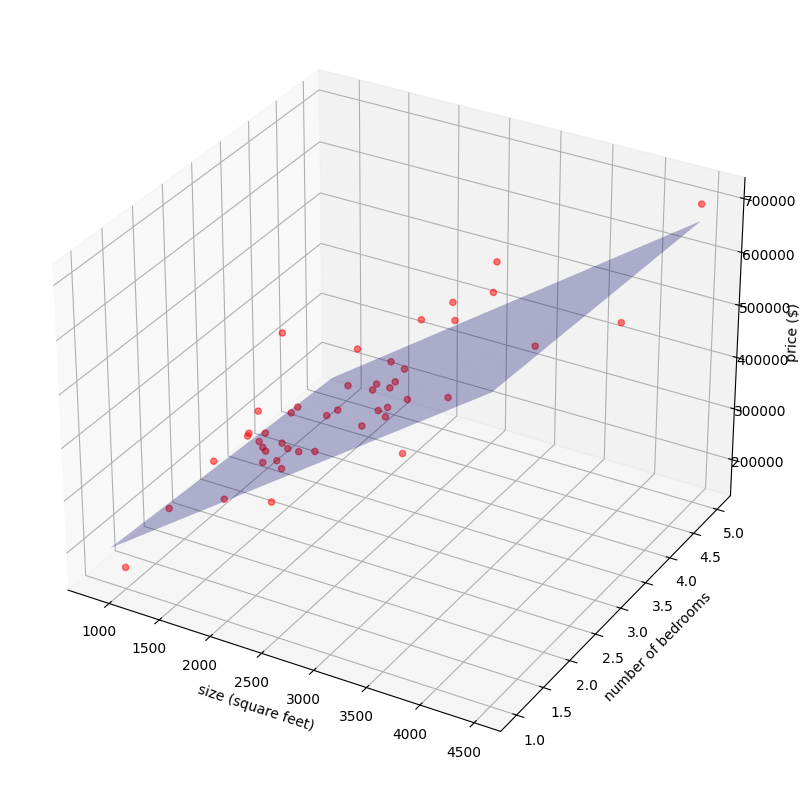

In [11]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['size (square feet)'], df['number of bedrooms']
           ,df['price ($)'], c='red', marker='o', alpha=0.5)
ax.plot_surface(x_surf, y_surf, predicted.reshape(x_surf.shape), color='b', alpha=0.3)

ax.set_xlabel('size (square feet)')
ax.set_ylabel('number of bedrooms')
ax.set_zlabel('price ($)')
plt.show()

- Comment:

    * The 3D plot visualizes the dataset (red scatter points) and the fitted Multivariate Linear Regression model (the blue plane).

    * The blue plane reasonably captures the upward trend of the house prices as both size and the number of bedrooms increase.

    * The data points are mostly scattered closely around the fitted plane, indicating that the linear model successfully learned the underlying relationship and is a good fit for this dataset.

## Predict Sample

In [12]:
sample = [1650, 3]

# Normalize the sample using the mean and standard deviation from the training set
sample_norm = standardize_test_set([sample], mu, sigma)

# Call the predict function to get the predicted price for the sample
y_predict = model.predict(sample_norm)

print(f'House price expected is {round(y_predict[0])}$')

House price expected is 293222$


## Save Results

In [13]:
#Save model
with open('model.json', 'w') as f:
    # Convert the learned parameters (theta) to a list and save it as JSON
    json.dump({'theta: ': model.theta.tolist()}, f)
print('Model saved successfully to model.json')

#Save prediction result
with open('price.json', 'w') as f:
    result = {
        'size (square feet)': sample[0],
        'number of bedrooms': sample[1],
        'price ($)': round(y_predict[0])
    }
    json.dump(result, f)

Model saved successfully to model.json
